In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('stackexchange_enhanced_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Question_ID                          5000 non-null   int64  
 1   User_ID                              5000 non-null   object 
 2   User_Reputation                      5000 non-null   int64  
 3   User_Type                            5000 non-null   object 
 4   Gold_Badges                          5000 non-null   int64  
 5   Silver_Badges                        5000 non-null   int64  
 6   Bronze_Badges                        5000 non-null   int64  
 7   Has_Custom_Avatar                    5000 non-null   bool   
 8   Accept_Rate                          2107 non-null   float64
 9   Tags                                 5000 non-null   object 
 10  Tag_Count                            5000 non-null   int64  
 11  Creation_Date_Readable        

In [13]:
df.describe()

,Question_ID,User_Reputation,Gold_Badges,Silver_Badges,Bronze_Badges,Accept_Rate,Tag_Count,Post_Age_Days,Word_Count,Code_Block_Count,...,Favorite_Count,View_Count,Objective_Comment_Count,Objective_Total_Comment_Words,Objective_Avg_Comment_Words,Objective_Time_To_First_Answer_Mins,Answer_Count,Max_Answer_Score,Avg_Answer_Score,Total_Answer_Words
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,2107.000000,5000.000000,5000.000000,5000.00000,5000.000000,...,5000.00000,5.000000e+03,5000.000000,5000.000000,5000.000000,2.551000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,467867.762600,13676.591000,4.550200,36.257000,62.808400,83.258662,2.399800,2610.665828,158.11020,1.055600,...,0.00100,6.012476e+04,0.800000,22.907200,6.804620,8.271827e+05,3.147800,13.651000,10.174504,215.829800
std,250296.163161,49816.048615,11.168403,109.216461,171.723576,17.233551,1.135702,1733.323954,200.47274,1.139284,...,0.03161,1.758278e+05,2.067766,72.332168,14.256254,1.752683e+06,3.783651,48.765767,36.323796,462.287466
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.770000,7.00000,0.000000,...,0.00000,5.900000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-2.000000,-2.000000,0.000000
25%,314205.750000,315.000000,0.000000,2.000000,7.000000,75.000000,2.000000,1179.922500,59.00000,0.000000,...,0.00000,5.680000e+02,0.000000,0.000000,0.000000,3.433000e+01,1.000000,0.000000,0.000000,0.000000
50%,514113.000000,1167.500000,1.000000,8.000000,15.000000,88.000000,2.000000,2479.705000,104.00000,1.000000,...,0.00000,1.930500e+03,0.000000,0.000000,0.000000,1.870000e+02,2.000000,0.000000,0.000000,17.500000
75%,686313.250000,5541.000000,4.000000,27.000000,45.250000,97.000000,3.000000,3714.945000,181.00000,1.000000,...,0.00000,2.546075e+04,1.000000,5.000000,5.000000,5.177997e+05,4.000000,10.000000,8.000000,238.000000
max,765298.000000,628691.000000,148.000000,1727.000000,2443.000000,100.000000,5.000000,6569.240000,3193.00000,20.000000,...,1.00000,2.876438e+06,26.000000,1332.000000,116.000000,8.242013e+06,101.000000,1106.000000,789.000000,6333.000000


In [14]:
df.head()

,Question_ID,User_ID,User_Reputation,User_Type,Gold_Badges,Silver_Badges,Bronze_Badges,Has_Custom_Avatar,Accept_Rate,Tags,...,Objective_Comment_Count,Objective_Total_Comment_Words,Objective_Avg_Comment_Words,Objective_Time_To_First_Answer_Mins,Answer_Count,Has_Accepted_Answer,Max_Answer_Score,Avg_Answer_Score,Total_Answer_Words,Link
0,246,60,21238,registered,7,30,28,False,75.0,"include, input",...,2,25,12.50,647474.02,7,False,464,233.0,645,https://tex.stackexchange.com/questions/246/wh...
1,823,35,23407,registered,17,46,32,True,82.0,"hyperref, color, boxes, links",...,1,57,57.00,314.92,8,False,494,494.0,34,https://tex.stackexchange.com/questions/823/re...
2,9363,1744,15055,registered,4,33,44,False,72.0,symbols,...,3,40,13.33,249.10,10,True,1106,721.5,373,https://tex.stackexchange.com/questions/9363/h...
3,1319,564,8541,registered,18,54,56,False,96.0,"typography, big-list, examples",...,0,0,0.00,956507.07,101,False,272,54.5,1080,https://tex.stackexchange.com/questions/1319/s...
4,8351,83,92989,registered,27,266,297,False,90.0,"macros, catcodes",...,3,37,12.33,NaN,1,False,0,0.0,0,https://tex.stackexchange.com/questions/8351/w...


In [15]:
df['User_ID'].value_counts()

User_ID
Unknown    159
117876      41
319072      35
322482      28
314693      25
          ... 
35514        1
2537         1
3391         1
7576         1
31102        1
Name: count, Length: 3284, dtype: int64

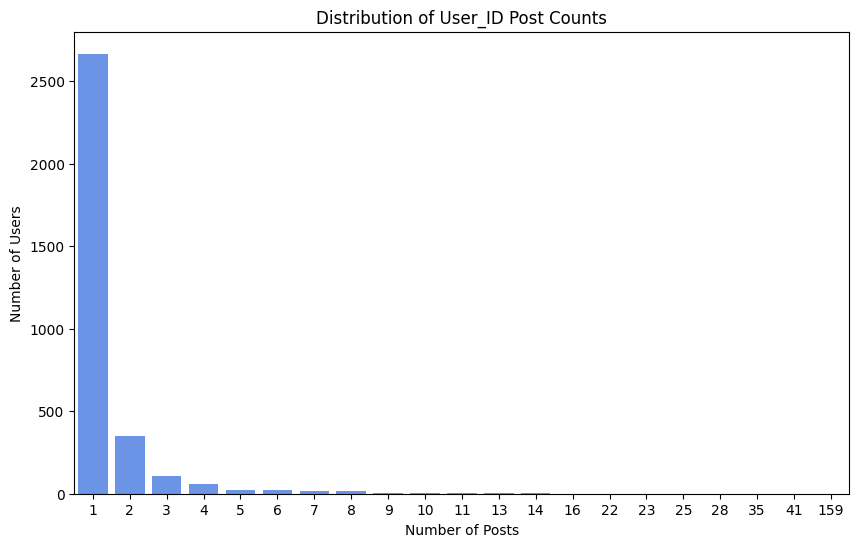

In [16]:
# Create a barplot of the distribution of the groupby counts of value counts of User_ID. That is - how if 10 users have 1 post, the 1 label will have a bar of 10.
user_id_counts = df['User_ID'].value_counts()
user_id_counts_grouped = user_id_counts.value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=user_id_counts_grouped.index, y=user_id_counts_grouped.values)
plt.title('Distribution of User_ID Post Counts')
plt.xlabel('Number of Posts')
plt.ylabel('Number of Users')
plt.show()

In [17]:
df['User_Type'].value_counts()

User_Type
registered        4724
does_not_exist     159
unregistered        99
moderator           18
Name: count, dtype: int64

In [18]:
# Check how many tag values there are

# Turn the 'Tags' column into a list of tags
df['Tags'] = df['Tags'].apply(lambda x: x.split(','))
# Create a new dataframe with the tags and their counts
tags_df = pd.DataFrame(df['Tags'].explode().value_counts()).reset_index()
tags_df.columns = ['Tag', 'Count']

In [19]:
# Check how many unique tags there are
unique_tags = tags_df['Tag'].nunique()
print(f'There are {unique_tags} unique tags in the dataset.')

There are 1566 unique tags in the dataset.


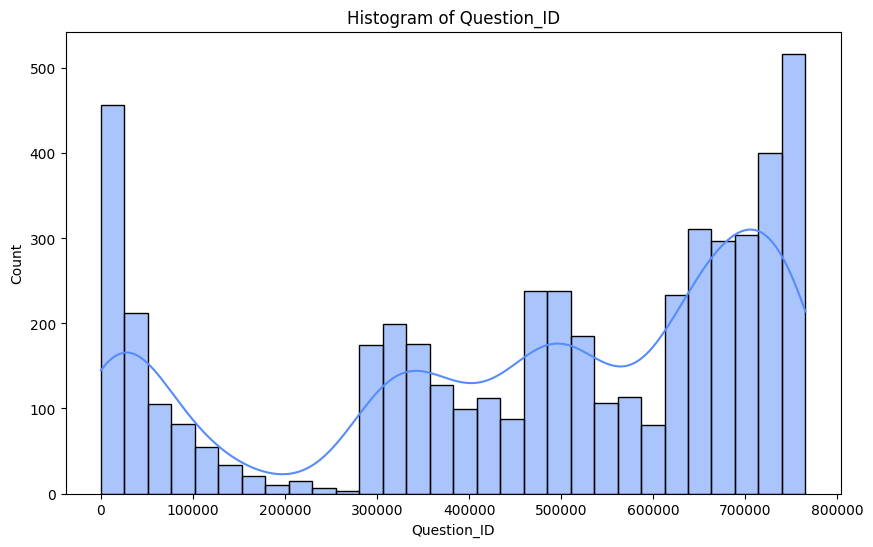

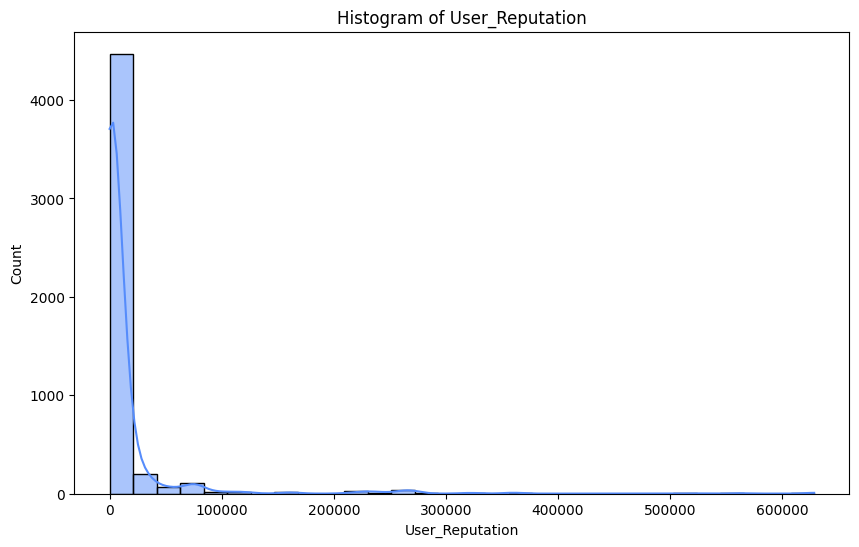

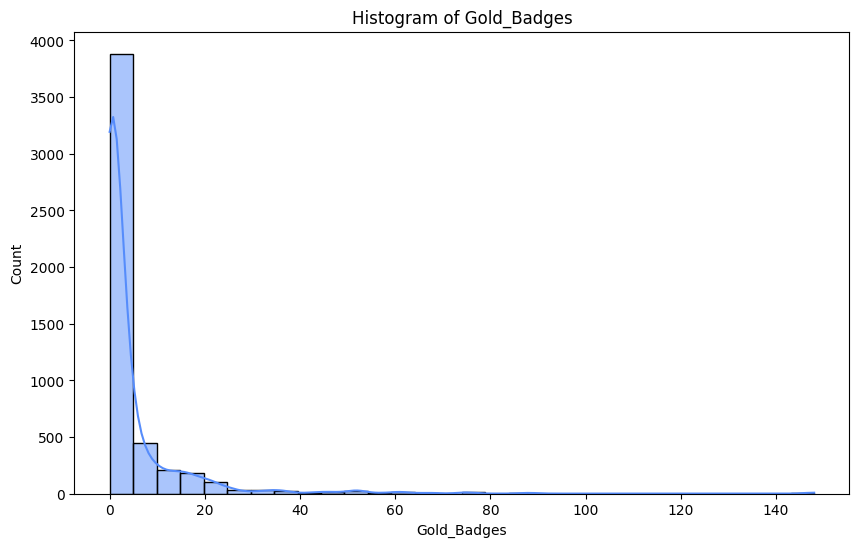

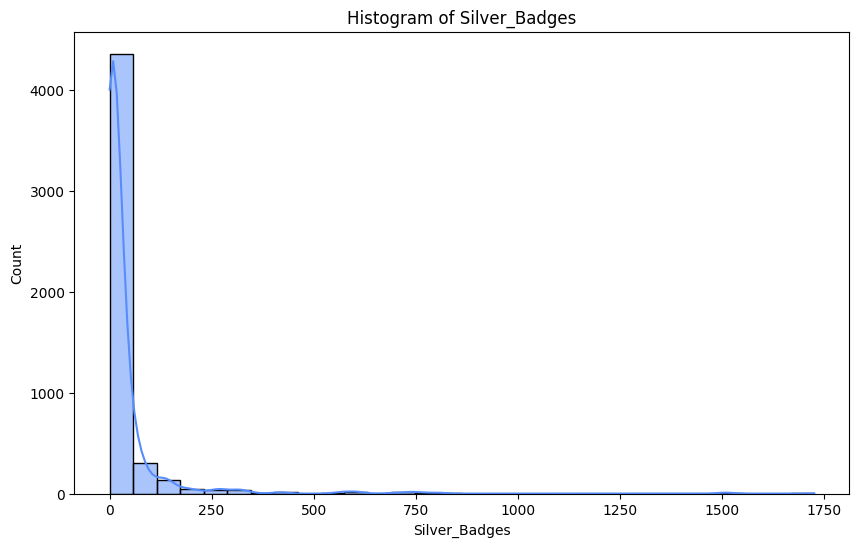

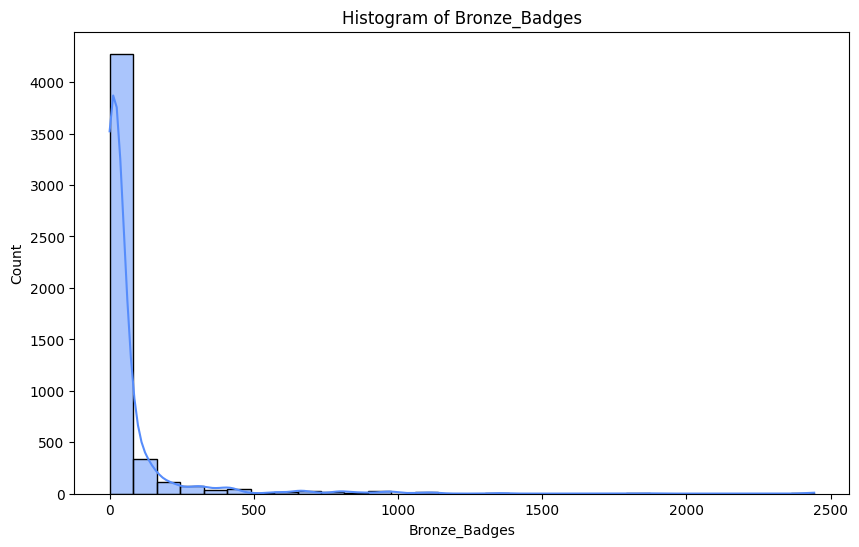

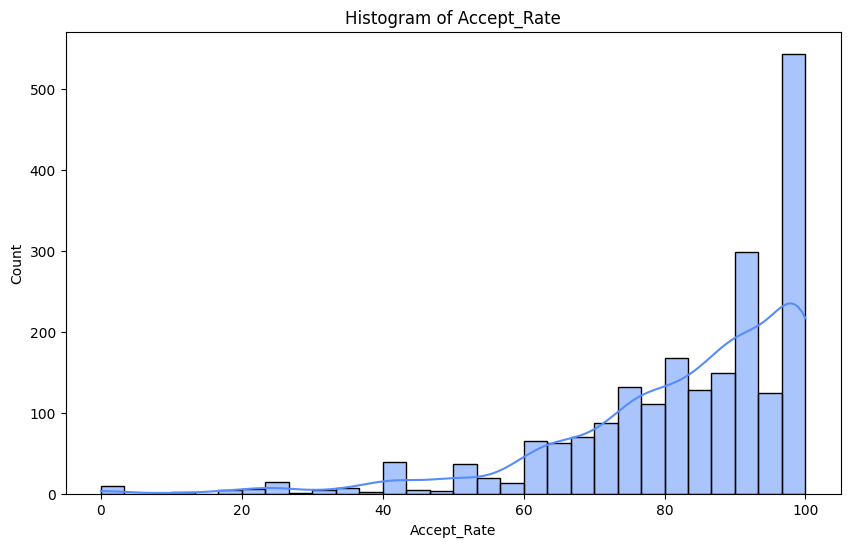

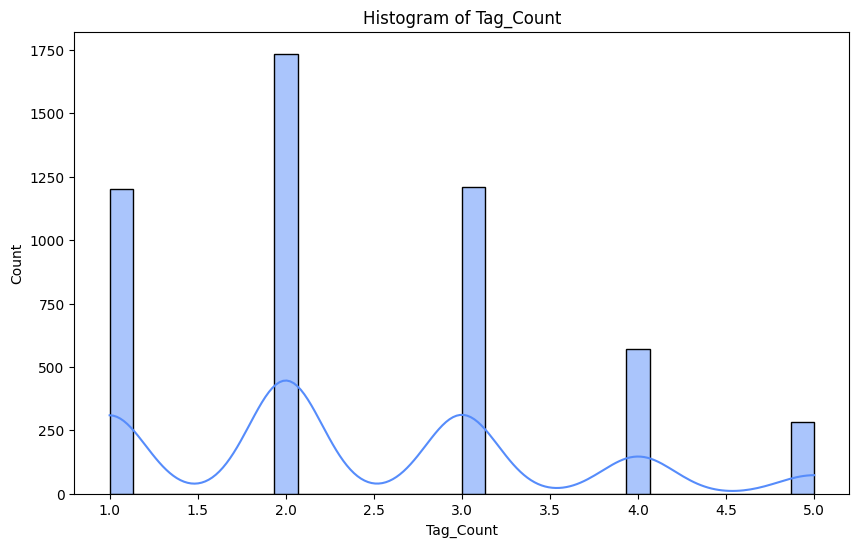

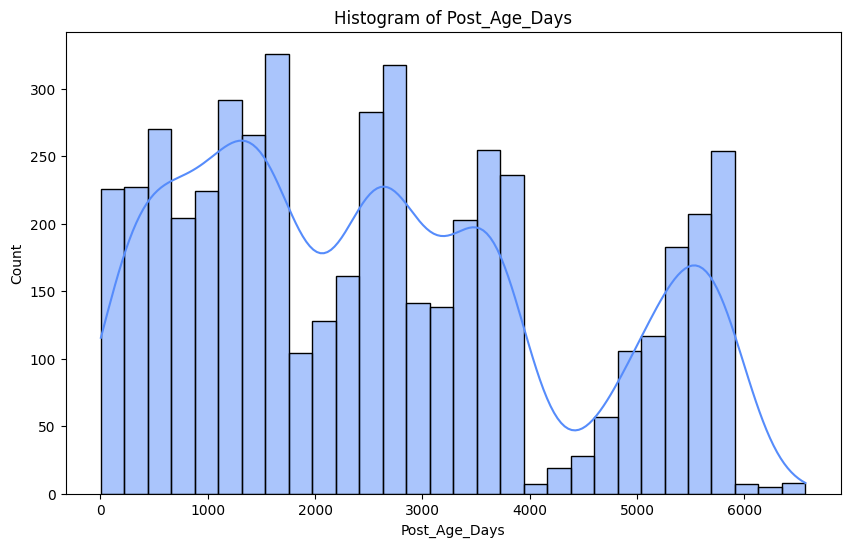

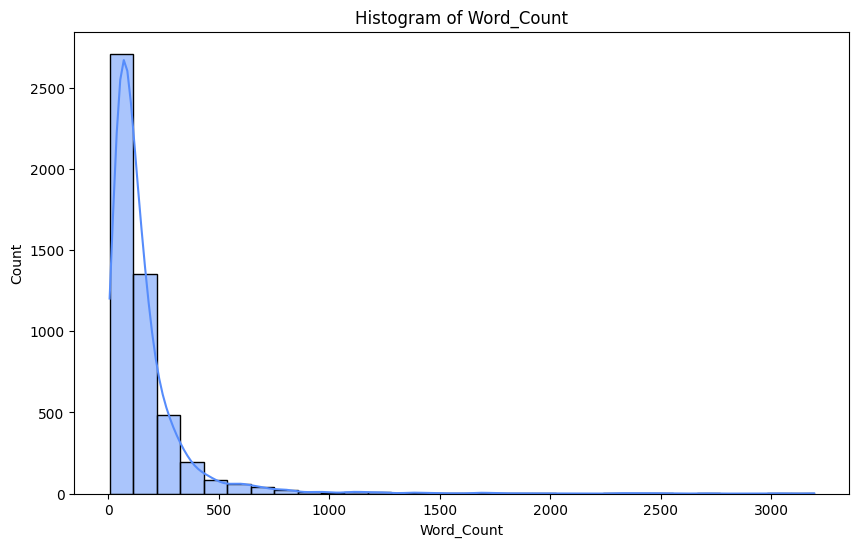

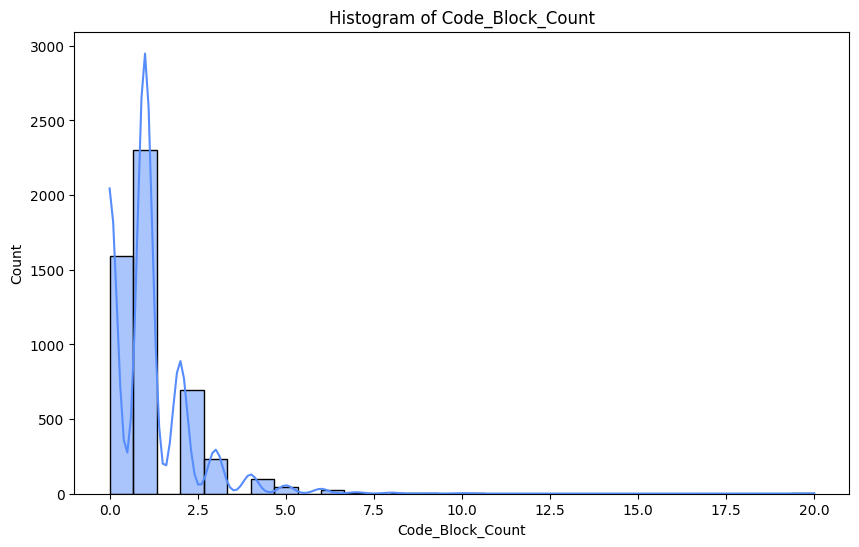

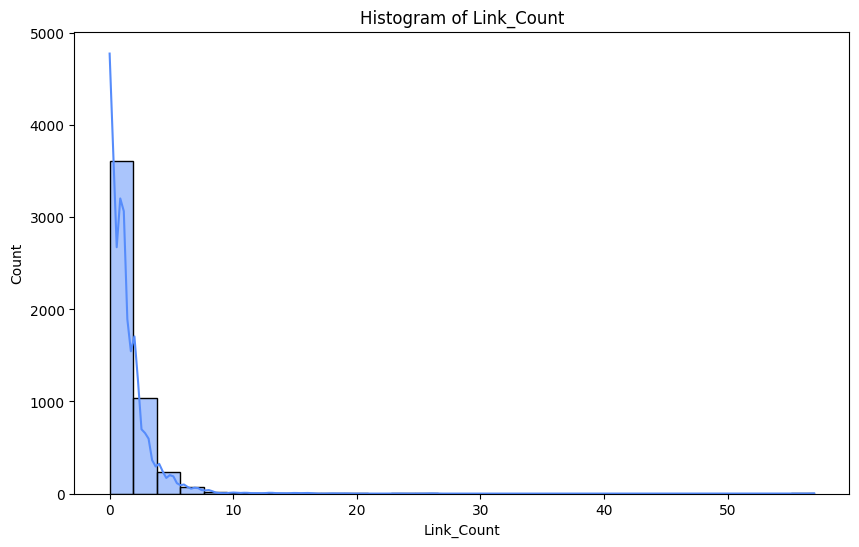

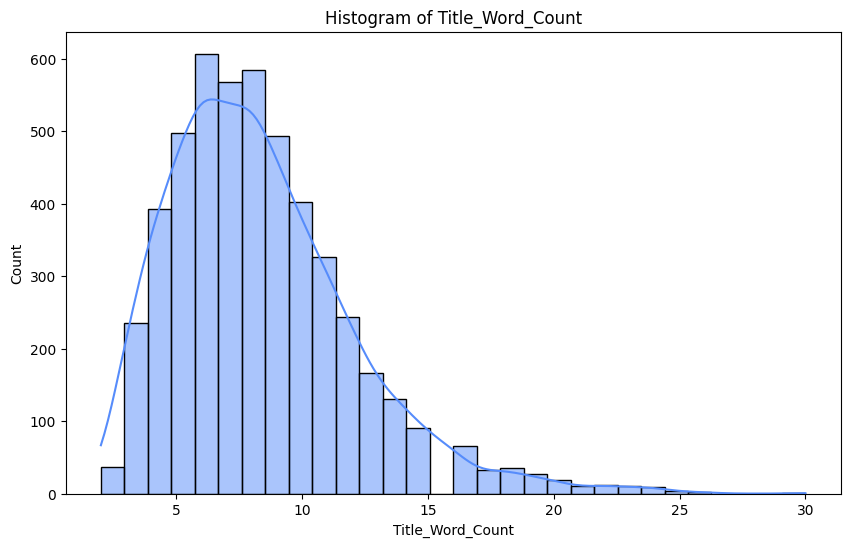

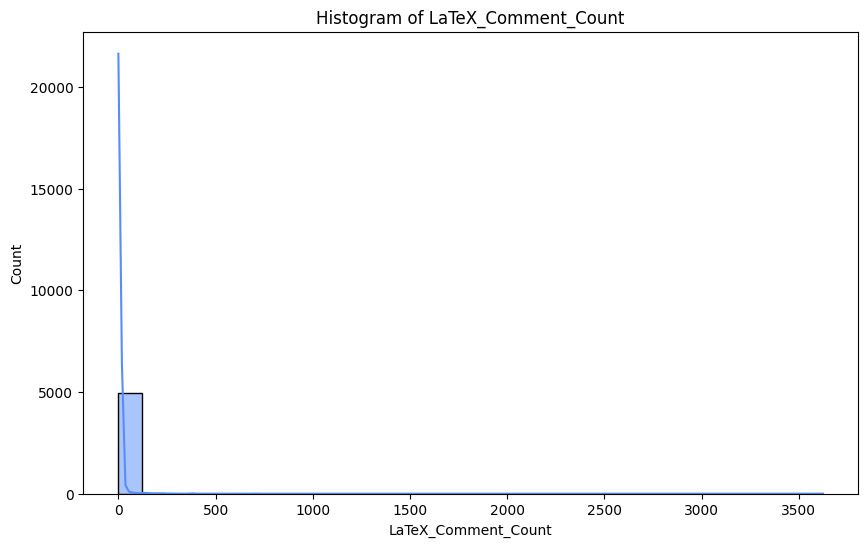

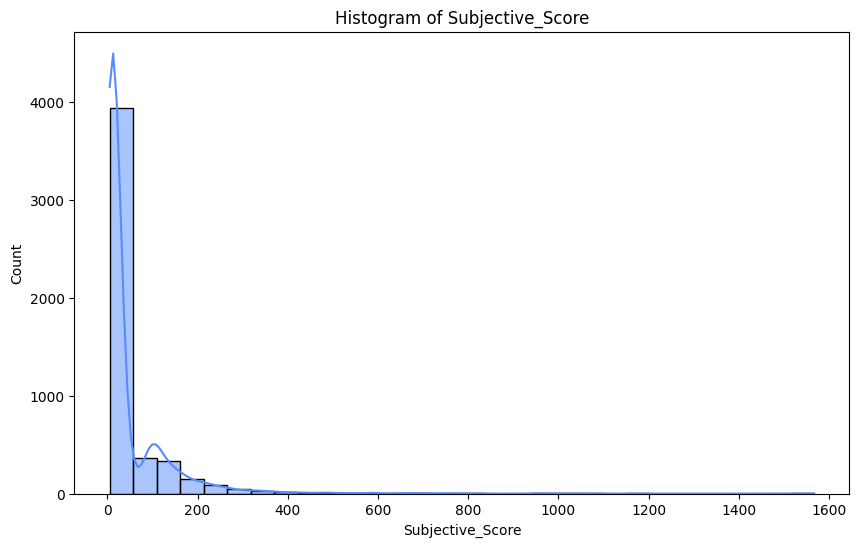

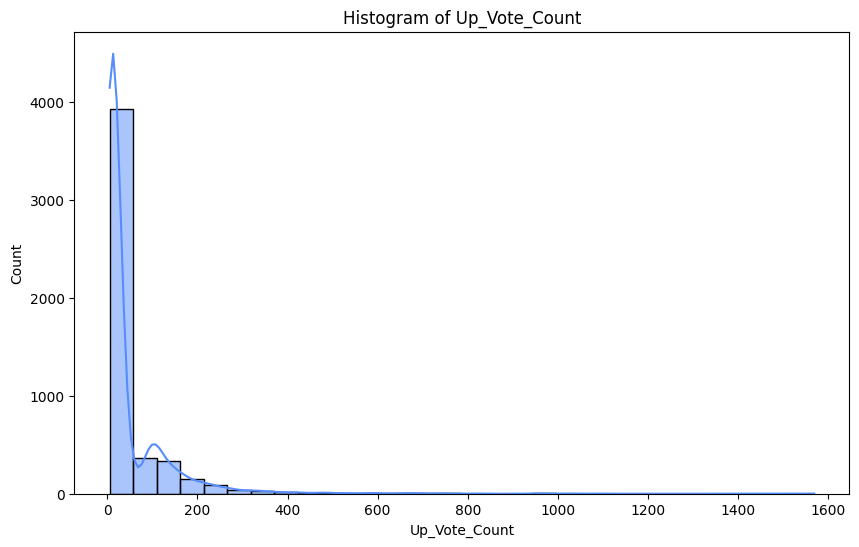

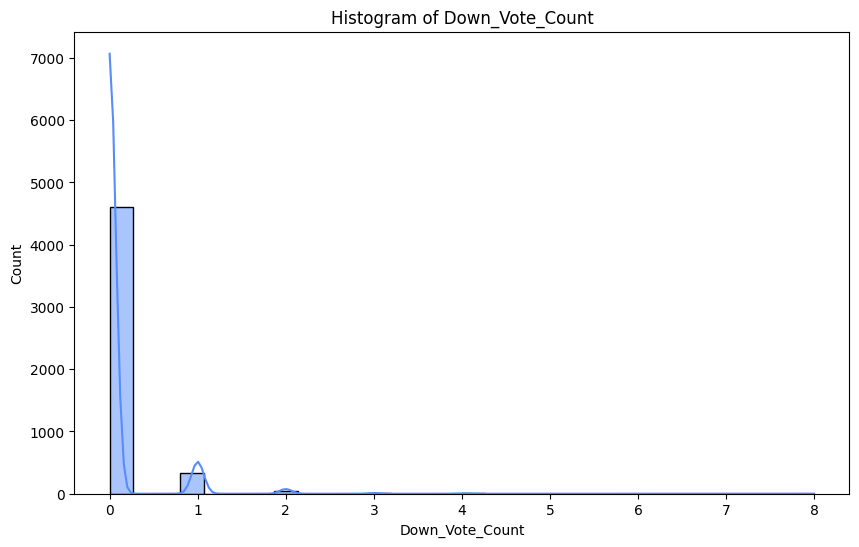

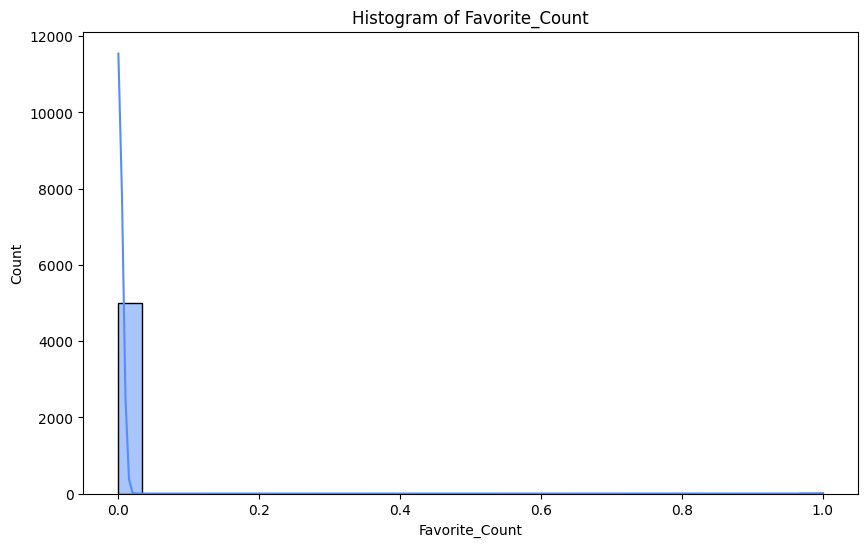

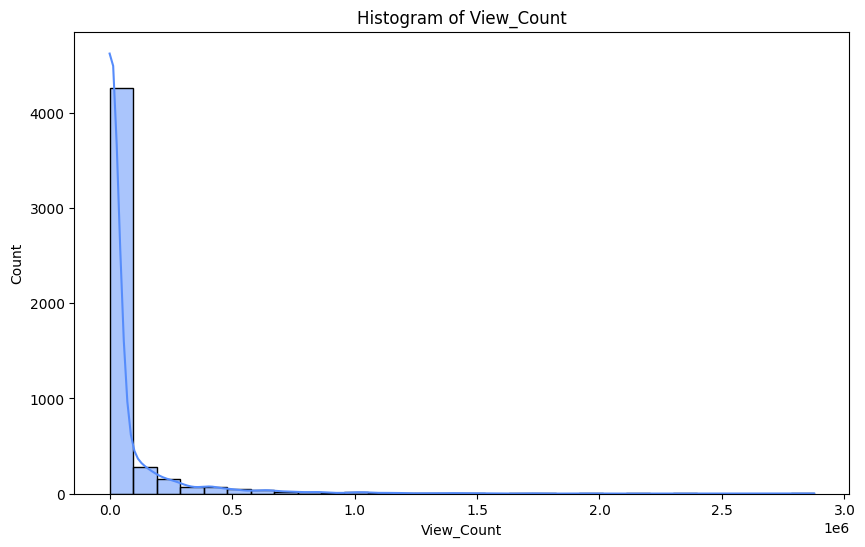

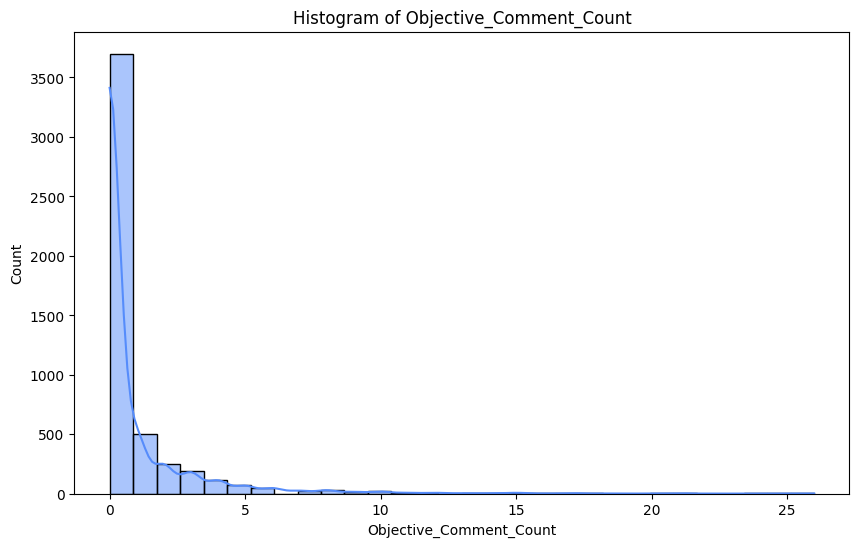

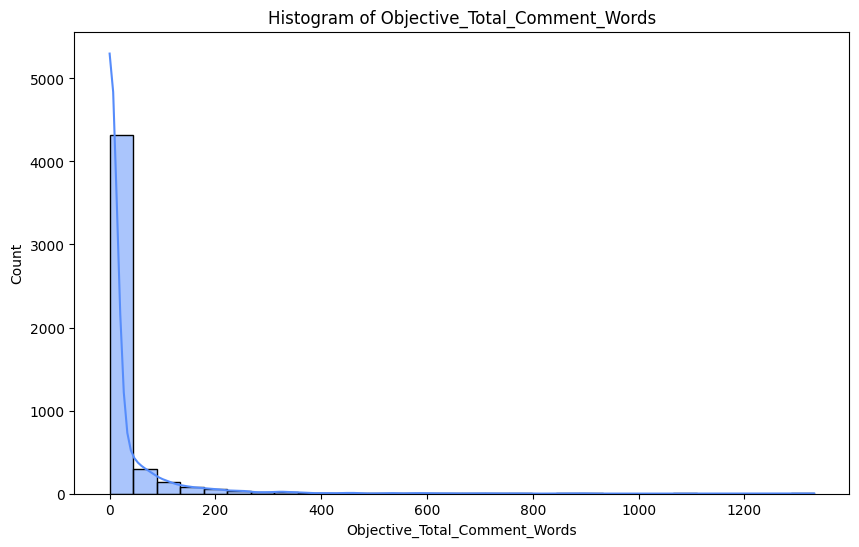

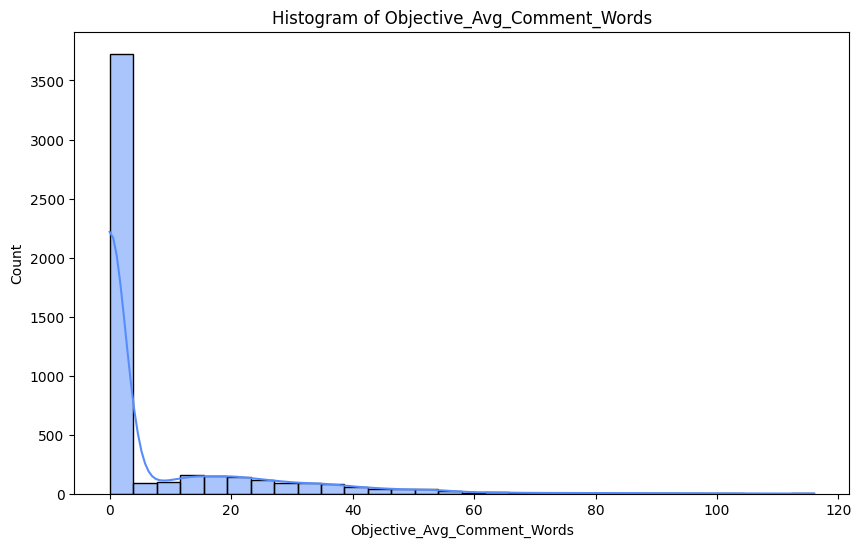

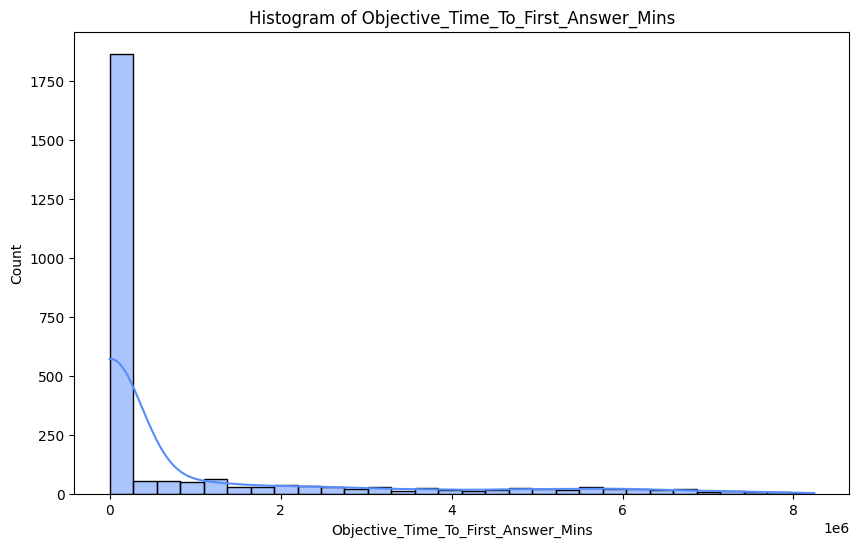

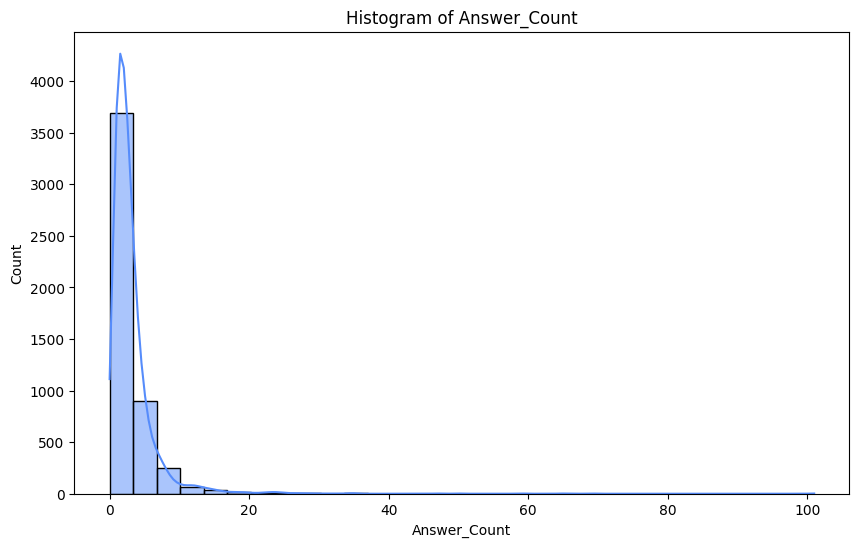

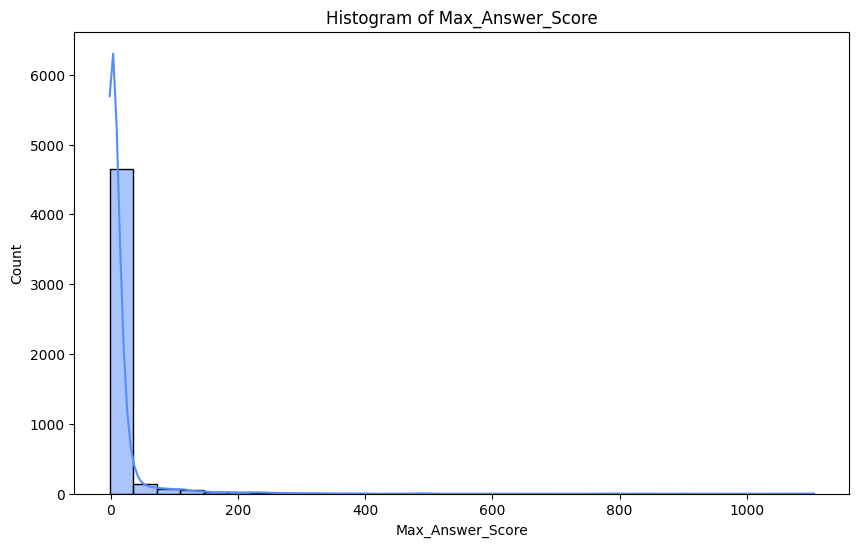

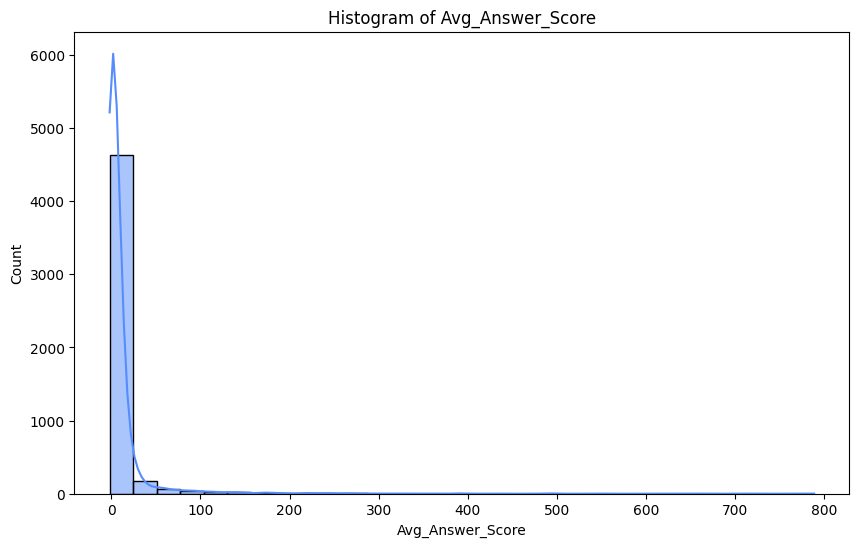

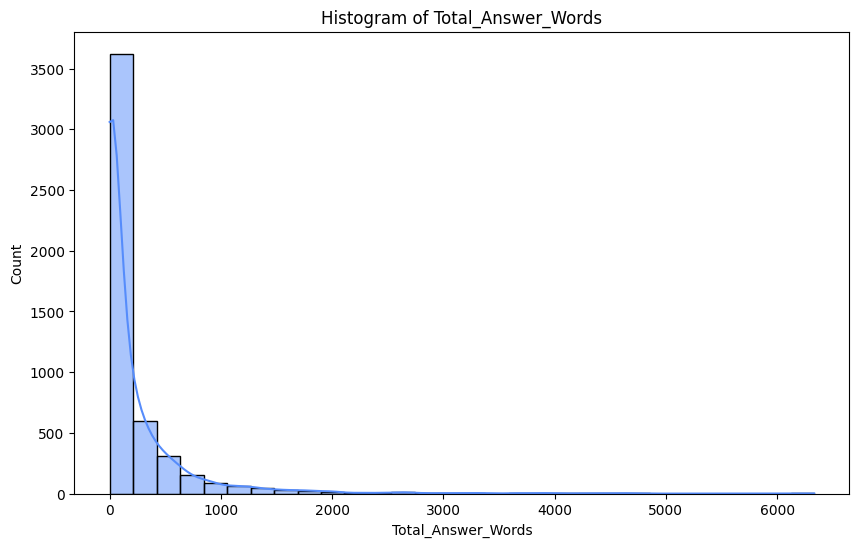

In [20]:
# Plot a histogram for every numeric feature in the dataset
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

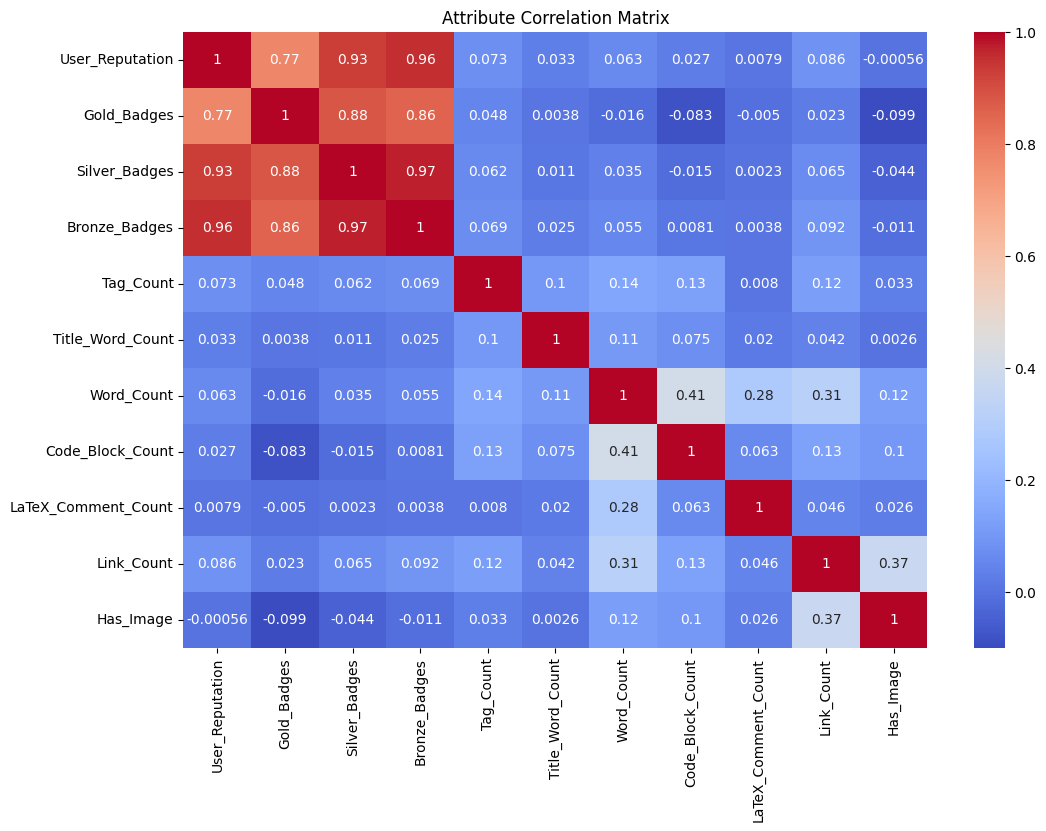

In [28]:
# Plot a correlation matrix where the colorbar limits are -1 and 1
cols_for_corr = [
    "User_Reputation",
    "Gold_Badges",
    "Silver_Badges",
    "Bronze_Badges",
    "Tag_Count",
    "Title_Word_Count",
    "Word_Count",
    "Code_Block_Count",
    "LaTeX_Comment_Count",
    "Link_Count",
    "Has_Image"
]

corr = df[cols_for_corr].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Attribute Correlation Matrix')
plt.show()